In [443]:
import pandas as pd
import bentoml
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
import sys
from pathlib import Path
project_root = Path.cwd().parents[0]
sys.path.insert(0, str(project_root))

from utils.tools import *

In [445]:
# --- CONFIGURATION ---

TEST_FILE = "test_data_rs_19.csv"
DATA_FILE = "2016_Building_Energy_Benchmarking.csv"

TEST_DATA_PATH = f"{project_root}\\data\\{TEST_FILE}"
DATA_PATH = f"{project_root}\\data\\{DATA_FILE}"
API_ENDPOINT = "http://localhost:3000" # Local
# API_ENDPOINT = "https://8s3mfvbefu.eu-west-3.awsapprunner.com"  # AWS
N_SAMPLES = 100 # Nombre de bâtiments à tester
YEAR = 2016 #Année doit être une valeur numérique
TIMEOUT = 30  # Timeout en secondes

In [446]:
print(f"Chargement des nouvelles données depuis '{DATA_PATH}'...")
try:
    X_test = pd.read_csv(TEST_DATA_PATH, sep=";")
    df_seattle = pd.read_csv(DATA_PATH, sep=",")
    # Year filter
    assert df_seattle.shape[0] > 0, f"Aucune donnée retrouvée pour l'année {YEAR}"
    print(f"Pour l'annéee {YEAR}, {df_seattle.shape[0]} lignes existes")
except FileNotFoundError:
    print(f"ERREUR : Fichier non trouvé. Vérifie le chemin dans la variable DATA_PATH.")
    exit()    

Chargement des nouvelles données depuis 'c:\Users\abguv\OneDrive\Desktop\Formation Data Engineer\Projets\Projet 6\analyse\data\2016_Building_Energy_Benchmarking.csv'...
Pour l'annéee 2016, 3376 lignes existes


In [447]:
# Appliquer le même nettoyage de base que pour l'entraînement
print("Nettoyage et filtrage des données...")
shape_before = df_seattle.shape

non_residential_types =[
    'NonResidential', 
    'Nonresidential COS', 
    'SPS-District K-12', 
    'Campus', 
    'Nonresidential WA'
]

df_non_residential = df_seattle[df_seattle["BuildingType"].isin(non_residential_types)].copy()
report_shape_changes(shape_before, df_non_residential.shape)

Nettoyage et filtrage des données...
Shape avant: (3376, 46)
Shape après: (1668, 46)
  ✂️  Lignes supprimées: 1708


In [448]:
shape_before = df_non_residential.shape
regex_residential = "Family|Residence|Residential"
mask_residential = (
                (df_non_residential["PrimaryPropertyType"].str.contains(regex_residential, case=False, na=False, regex=True))
                |(df_non_residential["LargestPropertyUseType"].str.contains(regex_residential, case=False, na=False, regex=True))
)
df_non_residential = df_non_residential.loc[~mask_residential].copy()
report_shape_changes(shape_before, df_non_residential.shape)

Shape avant: (1668, 46)
Shape après: (1628, 46)
  ✂️  Lignes supprimées: 40


In [449]:
df_non_residential.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

In [450]:
col = "PropertyGFABuilding(s)"
df_non_residential[col] = pd.to_numeric(df_non_residential[col], errors='coerce')
assert df_non_residential[col].dtype in ['float64', 'int64']
print(f"NaN count: {df_non_residential[col].isna().sum()}")

NaN count: 0


In [451]:
col = "PropertyGFAParking"
df_non_residential[col] = pd.to_numeric(df_non_residential[col], errors='coerce')
assert df_non_residential[col].dtype in ['float64', 'int64']
print(f"NaN count: {df_non_residential[col].isna().sum()}")

NaN count: 0


In [452]:
col = "SiteEnergyUse(kBtu)"
df_non_residential[col] = pd.to_numeric(df_non_residential[col], errors='coerce')
assert df_non_residential[col].dtype in ['float64', 'int64']
print(f"NaN count: {df_non_residential[col].isna().sum()}")

NaN count: 2


In [453]:
shape_before = df_non_residential.shape
df_non_residential = df_non_residential.dropna(subset=col)
report_shape_changes(shape_before,df_non_residential.shape)

Shape avant: (1628, 46)
Shape après: (1626, 46)
  ✂️  Lignes supprimées: 2


In [454]:
# Harmonisation de types
df_non_residential["CouncilDistrictCode"]  = df_non_residential["CouncilDistrictCode"].astype("str")

# Capitalisation de chaque mot dans "Neighborhood"
df_non_residential["Neighborhood"] = df_non_residential["Neighborhood"].str.title()

# Mapping des valeurs catégoriques manquantes
# df_non_residential["ComplianceStatus"] = df_non_residential["ComplianceStatus"].replace({
#     "Not Compliant": "Non-Compliant"
# })

In [455]:
shape_before = df_non_residential.shape
high = df_non_residential["SiteEnergyUse(kBtu)"].quantile(q=0.99)
mask = df_non_residential["SiteEnergyUse(kBtu)"] < high
df_non_residential = df_non_residential.loc[mask,:].copy()
report_shape_changes(shape_before, df_non_residential.shape)

Shape avant: (1626, 46)
Shape après: (1609, 46)
  ✂️  Lignes supprimées: 17


In [456]:
# Garder que les données que le modèle n'a jamais vu
shape_before = df_non_residential.shape
# df_non_residential = df_non_residential.loc[X_test.index].copy()
mask = X_test.index.intersection(df_non_residential.index)
df_non_residential = df_non_residential.loc[mask,:]
report_shape_changes(shape_before, df_non_residential.shape)
print(f"Test ratio : {df_non_residential.shape[0] / shape_before[0]:.2f}")

Shape avant: (1609, 46)
Shape après: (289, 46)
  ✂️  Lignes supprimées: 1320
Test ratio : 0.18


In [457]:
# Colonnes requises par notre API (basé sur validation.py)
required_columns = [
    "OSEBuildingID", #  Util pour le relevé d'erreurs
    "BuildingType", "CouncilDistrictCode", "Neighborhood", "LargestPropertyUseType",
    "ComplianceStatus", "YearBuilt", "NumberofBuildings", "NumberofFloors",
    "PropertyGFAParking", "PropertyGFABuilding(s)", "ENERGYSTARScore",
    "ListOfAllPropertyUseTypes", # On le renommera en AllPropertyUseTypes
    "SiteEnergyUse(kBtu)" # Notre vérité terrain pour comparer
]
# Features qui ne doivent pas être vide
mandatory_columns  = [col for col in required_columns if col != "ENERGYSTARScore"]

# On supprime les lignes où il manque une donnée essentielle
df_test = df_non_residential[required_columns].dropna(subset=mandatory_columns)
df_test


,OSEBuildingID,BuildingType,CouncilDistrictCode,Neighborhood,LargestPropertyUseType,ComplianceStatus,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),ENERGYSTARScore,ListOfAllPropertyUseTypes,SiteEnergyUse(kBtu)
0,1,NonResidential,7,Downtown,Hotel,Compliant,1927,1.0,12,0,88434,60.0,Hotel,7226362.5
1,2,NonResidential,7,Downtown,Hotel,Compliant,1996,1.0,11,15064,88502,61.0,"Hotel, Parking, Restaurant",8387933.0
2,3,NonResidential,7,Downtown,Hotel,Compliant,1969,1.0,41,196718,759392,43.0,Hotel,72587024.0
3,5,NonResidential,7,Downtown,Hotel,Compliant,1926,1.0,10,0,61320,56.0,Hotel,6794584.0
4,8,NonResidential,7,Downtown,Hotel,Compliant,1980,1.0,18,62000,113580,75.0,"Hotel, Parking, Swimming Pool",14172606.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,429,NonResidential,7,Downtown,Office,Compliant,1923,1.0,11,0,102846,96.0,"Office, Retail Store",5327249.5
300,430,NonResidential,7,Downtown,Office,Compliant,1925,1.0,4,0,52800,83.0,"Office, Restaurant",2429021.0
301,432,Campus,7,Downtown,Parking,Compliant,1913,3.0,10,0,258497,NaN,"Data Center, Office, Parking, Restaurant, Reta...",20779796.0
302,433,NonResidential,7,Downtown,Retail Store,Compliant,1929,1.0,8,0,861702,NaN,"Other, Retail Store",17666646.0


In [458]:
df_test.dtypes.unique()

array([dtype('int64'), dtype('O'), dtype('float64')], dtype=object)

In [459]:
df_test_numeric = df_test.select_dtypes(include=["int64", "float64"])
missing_summary(df_test_numeric)

,col,missing_count,missing_pct
0,ENERGYSTARScore,82,28.37


In [460]:
# Nombre de valeurs négatives par colonne
neg_counts = (df_test_numeric < 0).sum()

# Nombre de zéros par colonne
zero_counts = (df_test_numeric == 0).sum()

# Combine les deux dans un seul DataFrame
df_check = pd.DataFrame({
    "negative_values": neg_counts,
    "zero_values": zero_counts
})

df_check

,negative_values,zero_values
OSEBuildingID,0,0
YearBuilt,0,0
NumberofBuildings,0,9
NumberofFloors,0,1
PropertyGFAParking,0,194
PropertyGFABuilding(s),0,0
ENERGYSTARScore,0,0
SiteEnergyUse(kBtu),0,9


In [461]:
# Supprime les zéros dans les features critiques
critical_cols = ["SiteEnergyUse(kBtu)", "NumberofBuildings", "NumberofFloors"]
zero_mask = (df_test[critical_cols] == 0).any(axis=1)
df_test = df_test[~zero_mask].copy()

In [462]:
df_test_numeric = df_test.select_dtypes(include=["int64", "float64"])
# Nombre de valeurs négatives par colonne
neg_counts = (df_test_numeric < 0).sum()

# Nombre de zéros par colonne
zero_counts = (df_test_numeric == 0).sum()

# Combine les deux dans un seul DataFrame
df_check = pd.DataFrame({
    "negative_values": neg_counts,
    "zero_values": zero_counts
})

df_check

,negative_values,zero_values
OSEBuildingID,0,0
YearBuilt,0,0
NumberofBuildings,0,0
NumberofFloors,0,0
PropertyGFAParking,0,179
PropertyGFABuilding(s),0,0
ENERGYSTARScore,0,0
SiteEnergyUse(kBtu),0,0


In [463]:
missing_summary(df_test.select_dtypes(include=["object"]))

,col,missing_count,missing_pct


In [464]:
# Nombre de valeurs négatives par colonne
neg_counts = (df_test_numeric < 0).sum()

# Nombre de zéros par colonne
zero_counts = (df_test_numeric == 0).sum()

# Combine les deux dans un seul DataFrame
df_check = pd.DataFrame({
    "negative_values": neg_counts,
    "zero_values": zero_counts
})

df_check

,negative_values,zero_values
OSEBuildingID,0,0
YearBuilt,0,0
NumberofBuildings,0,0
NumberofFloors,0,0
PropertyGFAParking,0,179
PropertyGFABuilding(s),0,0
ENERGYSTARScore,0,0
SiteEnergyUse(kBtu),0,0


In [465]:
# Remplacement des NaN par None
print(f"None count before : {df_test["ENERGYSTARScore"].apply(lambda x: x is None).sum()} | dtype: {df_test['ENERGYSTARScore'].dtype}")

df_test["ENERGYSTARScore"] = df_test["ENERGYSTARScore"].replace({np.nan: None}).astype("object")

print(f"None count after : {df_test["ENERGYSTARScore"].apply(lambda x: x is None).sum()} | dtype: {df_test['ENERGYSTARScore'].dtype}")

None count before : 0 | dtype: float64
None count after : 70 | dtype: object


In [466]:
# On prend un échantillon aléatoire
if len(df_test) > N_SAMPLES:
    df_sample = df_test.sample(n=N_SAMPLES, random_state=42)
else:
    df_sample = df_test # Si on a moins de 10 lignes valides, on prend tout
    
print(f"{len(df_sample)} bâtiments sélectionnés pour le test.\n")
df_sample

100 bâtiments sélectionnés pour le test.



,OSEBuildingID,BuildingType,CouncilDistrictCode,Neighborhood,LargestPropertyUseType,ComplianceStatus,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFAParking,PropertyGFABuilding(s),ENERGYSTARScore,ListOfAllPropertyUseTypes,SiteEnergyUse(kBtu)
33,40,NonResidential,4,Northeast,Hotel,Compliant,1994,1.0,4,0,81871,29.0,Hotel,6.668568e+06
130,214,SPS-District K-12,1,Delridge,K-12 School,Error - Correct Default Data,1963,1.0,1,0,145341,75.0,K-12 School,5.499097e+06
89,131,NonResidential,4,Northeast,Other,Compliant,1941,1.0,4,0,56521,None,Other,6.357632e+06
143,231,SPS-District K-12,4,Lake Union,K-12 School,Error - Correct Default Data,2010,1.0,3,0,127776,75.0,K-12 School,4.748137e+06
225,349,NonResidential,7,Downtown,Office,Compliant,1991,1.0,29,197231,438072,95.0,"Office, Parking",1.822122e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179,286,SPS-District K-12,4,Northeast,K-12 School,Error - Correct Default Data,2006,1.0,3,0,269297,80.0,K-12 School,1.049834e+07
77,114,NonResidential,7,Magnolia / Queen Anne,Office,Compliant,2010,1.0,6,303707,616891,93.0,"Office, Other, Parking",3.666704e+07
2,3,NonResidential,7,Downtown,Hotel,Compliant,1969,1.0,41,196718,759392,43.0,Hotel,7.258702e+07
86,125,SPS-District K-12,2,Greater Duwamish,K-12 School,Error - Correct Default Data,1957,1.0,1,0,130862,61.0,K-12 School,6.456026e+06


In [467]:
df_sample.to_csv(
    TEST_DATA_PATH.split(".")[0] + '_samples' + ".csv",
    sep=";",
    index=False    
)

🧪 TEST DE L'API EN PRODUCTION SUR DES DONNÉES RÉELLES

📊 Échantillon à tester :
   - Nombre de bâtiments : 100
   - Colonnes disponibles : ['OSEBuildingID', 'BuildingType', 'CouncilDistrictCode', 'Neighborhood', 'LargestPropertyUseType', 'ComplianceStatus', 'YearBuilt', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'ENERGYSTARScore', 'ListOfAllPropertyUseTypes', 'SiteEnergyUse(kBtu)']

🔄 Appels API en cours...


Prédictions: 100%|██████████| 100/100 [00:13<00:00,  7.68it/s]



📈 ANALYSE DES RÉSULTATS

📊 Métriques de performance :
   - Nombre de prédictions réussies : 100
   - MAE (Mean Absolute Error)      : 4,415,209.31 kBtu
   - RMSE (Root Mean Squared Error) : 8,599,078.03 kBtu
   - R² Score                       : 0.6334
   - MAPE (Mean Abs % Error)        : 35.42%

⚠️  Warnings :
   - Prédictions avec warnings : 24/100 (24.0%)

   Détails des warnings :
      Index 89: ['Avertissement : ENERGYSTARScore non fourni, remplacé par la médiane.La prédiction peut être moins précise.']
      Index 302: ['Avertissement : ENERGYSTARScore non fourni, remplacé par la médiane.La prédiction peut être moins précise.']
      Index 223: ['Avertissement : ENERGYSTARScore non fourni, remplacé par la médiane.La prédiction peut être moins précise.']
      Index 117: ['Avertissement : ENERGYSTARScore non fourni, remplacé par la médiane.La prédiction peut être moins précise.']
      Index 122: ['Avertissement : ENERGYSTARScore non fourni, remplacé par la médiane.La prédictio

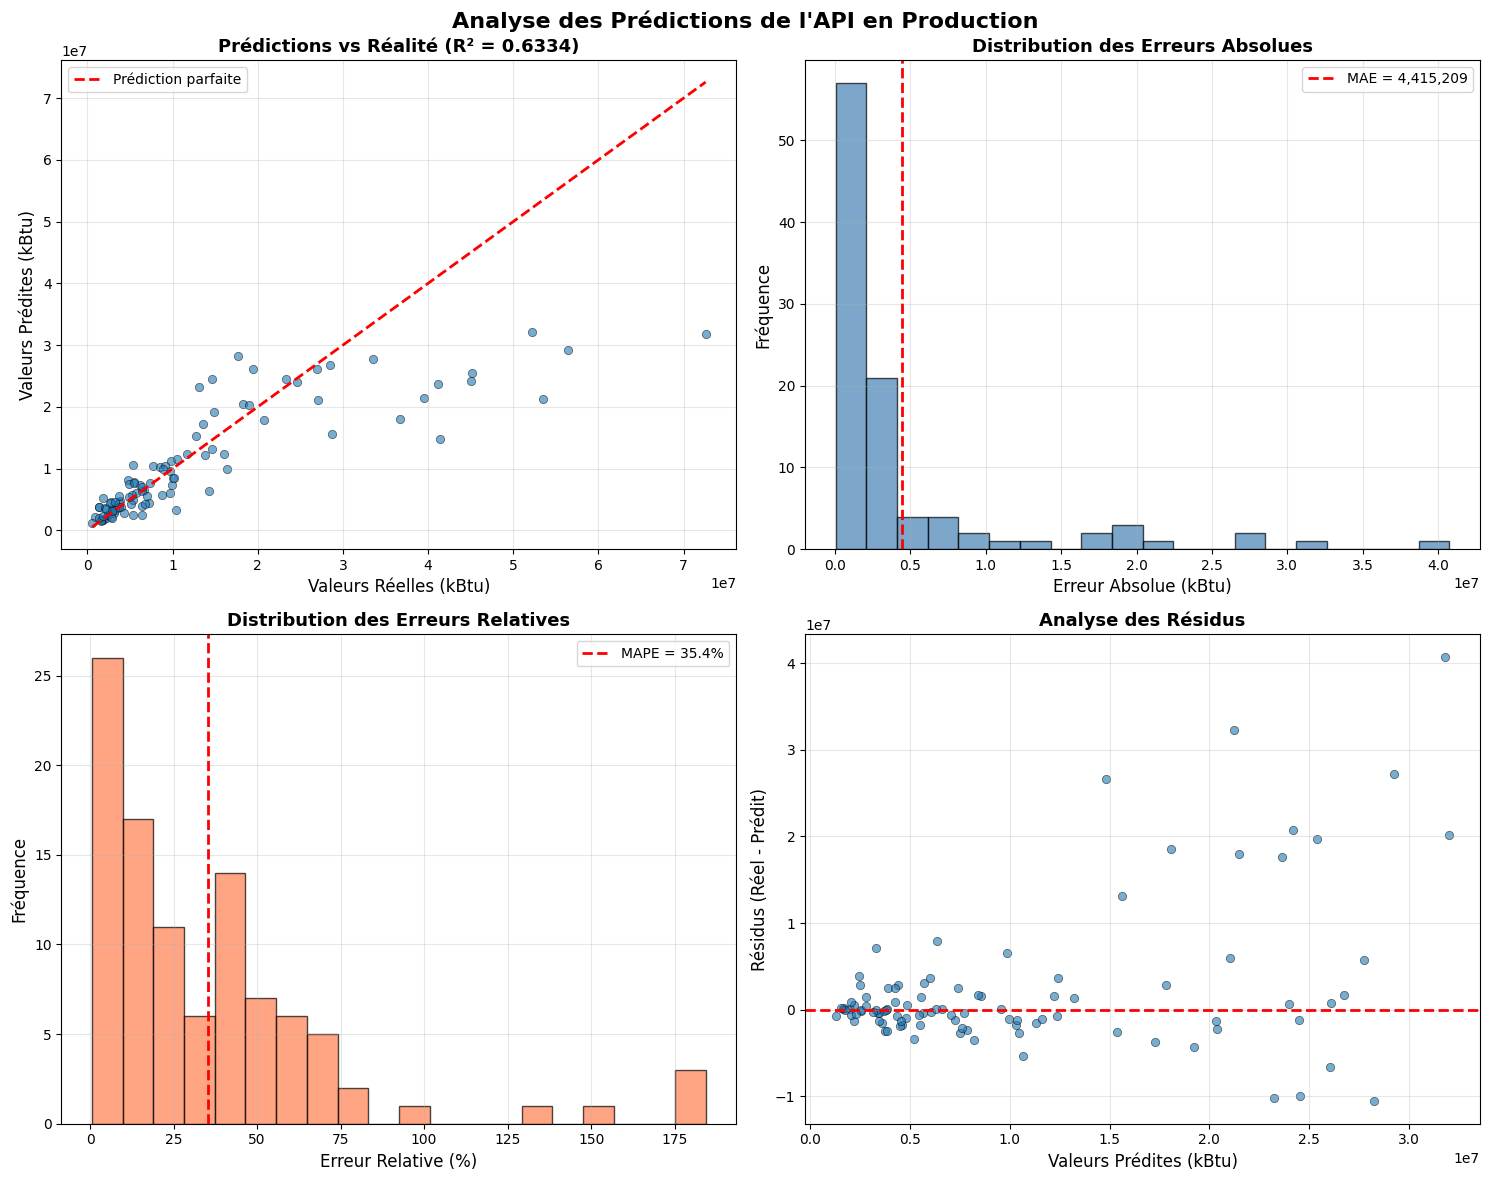


💾 Résultats sauvegardés dans 'resultats_api_production.csv'

✅ Aucune erreur d'API ! Tous les appels ont réussi.

🎉 TESTS TERMINÉS !


In [468]:
print("="*80)
print("🧪 TEST DE L'API EN PRODUCTION SUR DES DONNÉES RÉELLES")
print("="*80)

# --- ÉTAPE 1 : PRÉPARER LES DONNÉES ---
print("\n📊 Échantillon à tester :")
print(f"   - Nombre de bâtiments : {len(df_sample)}")
print(f"   - Colonnes disponibles : {list(df_sample.columns)}")

# --- ÉTAPE 2 : INTERROGER L'API EN BOUCLE ---
print("\n🔄 Appels API en cours...")

results = []
errors = []

with bentoml.SyncHTTPClient(API_ENDPOINT, timeout=TIMEOUT) as client:
    for index, row in tqdm(df_sample.iterrows(), total=len(df_sample), desc="Prédictions"):
        
        # Préparer le payload JSON pour l'API
        payload = {
            # "BuildingType": str(row["BuildingType"]),
            # "CouncilDistrictCode": str(row["CouncilDistrictCode"]),
            # "Neighborhood": str(row["Neighborhood"]),
            "LargestPropertyUseType": str(row["LargestPropertyUseType"]),
            # "ComplianceStatus": str(row["ComplianceStatus"]),
            "ListOfAllPropertyUseTypes": str(row["ListOfAllPropertyUseTypes"]),
            "YearBuilt": int(row["YearBuilt"]),
            "NumberofBuildings": int(row["NumberofBuildings"]),
            "NumberofFloors": int(row["NumberofFloors"]),
            "PropertyGFAParking": float(row["PropertyGFAParking"]),
            "PropertyGFABuilding_s_": float(row["PropertyGFABuilding(s)"]),
            # "ENERGYSTARScore": float(row["ENERGYSTARScore"]),
            "ENERGYSTARScore": row["ENERGYSTARScore"],
        }

        try:
            # Envoyer la requête
            response = client.predict(data=payload)
            
            # Stocker les résultats
            results.append({
                "index": index,
                "OSEBuildingID": row["OSEBuildingID"],
                "valeur_reelle": float(row["SiteEnergyUse(kBtu)"]),
                "valeur_predite": float(response.get("predicted_SiteEnergyUse(kBtu)")),
                "erreur_absolue": abs(float(row["SiteEnergyUse(kBtu)"]) - float(response.get("predicted_SiteEnergyUse(kBtu)"))),
                "erreur_relative_pct": abs(float(row["SiteEnergyUse(kBtu)"]) - float(response.get("predicted_SiteEnergyUse(kBtu)"))) / float(row["SiteEnergyUse(kBtu)"]) * 100,
                "warnings": response.get("warning_messages", None),
                "has_warning": bool(response.get("warning_messages"))
            })
            
        except Exception as e:
            errors.append({
                "index": index,
                "error": str(e),
                "payload": payload
            })
            print(f"\n⚠️  Erreur à l'index {index}: {e}")

# --- ÉTAPE 3 : ANALYSER LES RÉSULTATS ---
print("\n" + "="*80)
print("📈 ANALYSE DES RÉSULTATS")
print("="*80)

if not results:
    print("❌ Aucune prédiction réussie !")
else:
    # Créer un DataFrame des résultats
    df_results = pd.DataFrame(results)
    
    # Métriques globales
    y_true = df_results["valeur_reelle"]
    y_pred = df_results["valeur_predite"]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = df_results["erreur_relative_pct"].mean()
    
    print(f"\n📊 Métriques de performance :")
    print(f"   - Nombre de prédictions réussies : {len(results)}")
    print(f"   - MAE (Mean Absolute Error)      : {mae:,.2f} kBtu")
    print(f"   - RMSE (Root Mean Squared Error) : {rmse:,.2f} kBtu")
    print(f"   - R² Score                       : {r2:.4f}")
    print(f"   - MAPE (Mean Abs % Error)        : {mape:.2f}%")
    
    # Statistiques sur les warnings
    nb_warnings = df_results["has_warning"].sum()
    print(f"\n⚠️  Warnings :")
    print(f"   - Prédictions avec warnings : {nb_warnings}/{len(results)} ({nb_warnings/len(results)*100:.1f}%)")
    
    if nb_warnings > 0:
        print(f"\n   Détails des warnings :")
        for idx, row in df_results[df_results["has_warning"]].iterrows():
            print(f"      Index {row['index']}: {row['warnings']}")
    
    # Top 5 meilleures prédictions
    print(f"\n✅ Top 5 meilleures prédictions (erreur absolue la plus faible) :")
    top_best = df_results.nsmallest(5, "erreur_absolue")[["index", "valeur_reelle", "valeur_predite", "erreur_absolue", "erreur_relative_pct"]]
    print(top_best.to_string(index=False))
    
    # Top 5 pires prédictions
    print(f"\n❌ Top 5 pires prédictions (erreur absolue la plus élevée) :")
    top_worst = df_results.nlargest(5, "erreur_absolue")[["index", "valeur_reelle", "valeur_predite", "erreur_absolue", "erreur_relative_pct"]]
    print(top_worst.to_string(index=False))
    
    # --- ÉTAPE 4 : VISUALISATIONS ---
    print(f"\n📊 Génération des graphiques...")
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle("Analyse des Prédictions de l'API en Production", fontsize=16, fontweight='bold')
    
    # 1. Scatter plot : Valeurs réelles vs prédites
    ax1 = axes[0, 0]
    ax1.scatter(y_true, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax1.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2, label='Prédiction parfaite')
    ax1.set_xlabel("Valeurs Réelles (kBtu)", fontsize=12)
    ax1.set_ylabel("Valeurs Prédites (kBtu)", fontsize=12)
    ax1.set_title(f"Prédictions vs Réalité (R² = {r2:.4f})", fontsize=13, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 2. Distribution des erreurs absolues
    ax2 = axes[0, 1]
    ax2.hist(df_results["erreur_absolue"], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax2.axvline(mae, color='red', linestyle='--', linewidth=2, label=f'MAE = {mae:,.0f}')
    ax2.set_xlabel("Erreur Absolue (kBtu)", fontsize=12)
    ax2.set_ylabel("Fréquence", fontsize=12)
    ax2.set_title("Distribution des Erreurs Absolues", fontsize=13, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # 3. Distribution des erreurs relatives (%)
    ax3 = axes[1, 0]
    ax3.hist(df_results["erreur_relative_pct"], bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax3.axvline(mape, color='red', linestyle='--', linewidth=2, label=f'MAPE = {mape:.1f}%')
    ax3.set_xlabel("Erreur Relative (%)", fontsize=12)
    ax3.set_ylabel("Fréquence", fontsize=12)
    ax3.set_title("Distribution des Erreurs Relatives", fontsize=13, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # 4. Résidus
    ax4 = axes[1, 1]
    residus = y_true - y_pred
    ax4.scatter(y_pred, residus, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax4.axhline(0, color='red', linestyle='--', linewidth=2)
    ax4.set_xlabel("Valeurs Prédites (kBtu)", fontsize=12)
    ax4.set_ylabel("Résidus (Réel - Prédit)", fontsize=12)
    ax4.set_title("Analyse des Résidus", fontsize=13, fontweight='bold')
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Sauvegarder les résultats
    df_results.to_csv("resultats_api_production.csv", index=False)
    print(f"\n💾 Résultats sauvegardés dans 'resultats_api_production.csv'")

# --- ÉTAPE 5 : RAPPORT DES ERREURS ---
if errors:
    print("\n" + "="*80)
    print(f"⚠️  ERREURS RENCONTRÉES ({len(errors)} échecs)")
    print("="*80)
    for err in errors:
        print(f"\n   Index {err['index']}:")
        print(f"   Erreur: {err['error']}")
        print(f"   Payload: {err['payload']}")
else:
    print("\n✅ Aucune erreur d'API ! Tous les appels ont réussi.")

print("\n" + "="*80)
print("🎉 TESTS TERMINÉS !")
print("="*80)